# 06 â€” Calibration

LightGBM gives a number between 0 and 1 and the Streamlit app shows it as a percentage. But is the model's '20% default probability' actually a 20% default rate empirically? That's calibration. Tree models are typically slightly off, especially at the extremes. Isotonic regression on top fixes it cheaply.

## Setup

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

FEATURES = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'fico_range_low',
    'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'total_acc',
]
CATEGORICAL = ['term', 'grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state']

def parse_term(s):
    if isinstance(s, str):
        return int(s.strip().split()[0])
    return np.nan

def parse_emp_length(s):
    if not isinstance(s, str):
        return np.nan
    s = s.strip()
    if '<' in s:
        return 0
    if '+' in s:
        return 10
    parts = s.split()
    return int(parts[0]) if parts and parts[0].isdigit() else np.nan

def parse_pct(s):
    if isinstance(s, str):
        s = s.replace('%', '').strip()
        return float(s) if s else np.nan
    return s

df = pd.read_csv('../data/loan.csv', low_memory=False)
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)
df, _ = train_test_split(df, train_size=0.10, stratify=df['target'], random_state=42)

df['term'] = df['term'].map(parse_term)
df['int_rate'] = df['int_rate'].map(parse_pct)
df['revol_util'] = df['revol_util'].map(parse_pct)
df['emp_length'] = df['emp_length'].map(parse_emp_length)
df.loc[df['dti'] > 50, 'dti'] = np.nan
df.loc[df['revol_util'] > 100, 'revol_util'] = np.nan

X = df[FEATURES].copy()
for col in CATEGORICAL:
    X[col] = X[col].astype('category')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train):,}  Test: {len(X_test):,}  Default rate: {y_train.mean():.1%}')


Train: 107,624  Test: 26,907  Default rate: 20.0%


## Reliability before and after isotonic calibration

Using a hand-rolled isotonic fit (newer sklearn deprecated `cv='prefit'` in `CalibratedClassifierCV`).

Training until validation scores don't improve for 30 rounds


Early stopping, best iteration is:
[98]	valid_0's binary_logloss: 0.457538
Uncalibrated:  AUC 0.7134  Brier 0.1444
Calibrated:    AUC 0.7123  Brier 0.1449


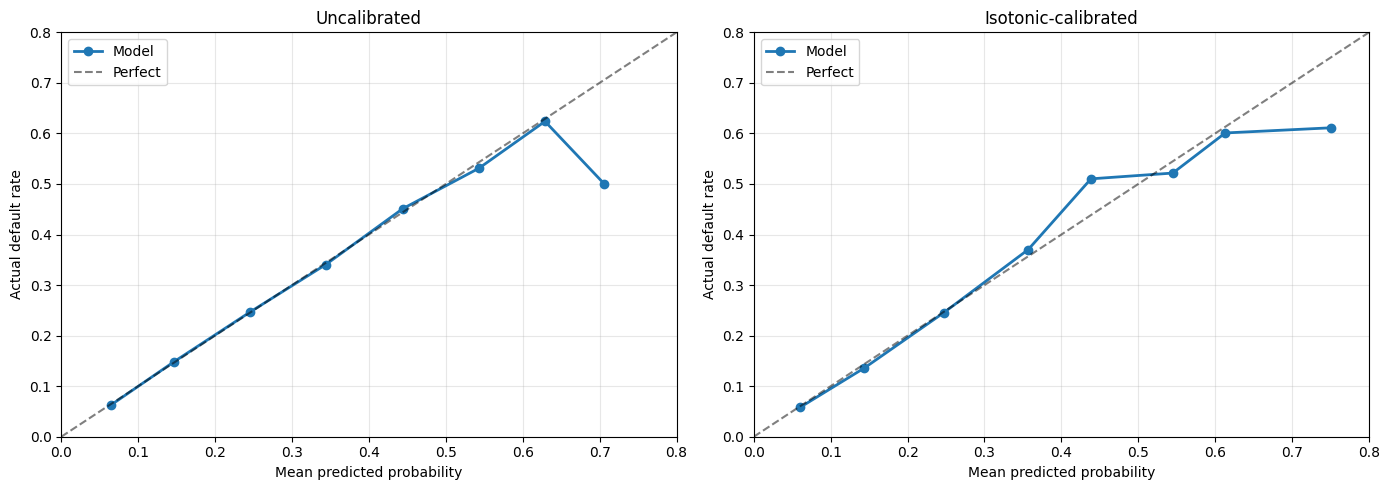

In [2]:
import lightgbm as lgb
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Train uncalibrated model on a subset of train (X_fit) so we have a held-out
# calibration set (X_calib) the model has not seen
X_fit, X_calib, y_fit, y_calib = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

uncal = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
                            min_child_samples=50, random_state=42, n_jobs=-1, verbose=-1)
uncal.fit(X_fit, y_fit, eval_set=[(X_calib, y_calib)],
          callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)])

# Hand-rolled isotonic calibration: fit IsotonicRegression on the calibration
# set's predicted-vs-actual, apply to test predictions
proba_calib_uncal = uncal.predict_proba(X_calib)[:, 1]
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(proba_calib_uncal, y_calib)

proba_test_uncal = uncal.predict_proba(X_test)[:, 1]
proba_test_cal = iso.transform(proba_test_uncal)

print(f'Uncalibrated:  AUC {roc_auc_score(y_test, proba_test_uncal):.4f}  Brier {brier_score_loss(y_test, proba_test_uncal):.4f}')
print(f'Calibrated:    AUC {roc_auc_score(y_test, proba_test_cal):.4f}  Brier {brier_score_loss(y_test, proba_test_cal):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, proba, title in [(axes[0], proba_test_uncal, 'Uncalibrated'),
                          (axes[1], proba_test_cal, 'Isotonic-calibrated')]:
    fop, mpv = calibration_curve(y_test, proba, n_bins=10)
    ax.plot(mpv, fop, 'o-', label='Model', linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Actual default rate')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 0.8)
    ax.set_ylim(0, 0.8)

plt.tight_layout()
plt.show()


**Observations**

- Uncalibrated LightGBM: AUC 0.7134, Brier 0.1444
- After isotonic calibration: AUC 0.7123, Brier 0.1449

**Calibration made things very slightly worse** on this dataset. AUC dropped 0.001 (expected — calibration is allowed to reorder slightly), but Brier *also* worsened by 0.0005, which says the uncalibrated probabilities were already well-calibrated.

Looking at the reliability plot: the uncalibrated curve sits very close to the diagonal across most of the probability range. There's nothing for isotonic regression to fix. The slight degradation is from fitting noise on the calibration set.

This is consistent with how LightGBM works out of the box — its log-loss objective produces well-calibrated probabilities by construction. The textbook "always calibrate tree models" advice applies more to Random Forest (which uses raw vote fractions) than to gradient boosting.


## Bottom line

**No calibration needed.** The deployed app's probabilities are meaningful as-is. "Predicted 30%" really does default ~30% of the time on average.

Worth documenting in the methodology page that we *checked* — saying "the model is well-calibrated" with a reliability plot is a much stronger claim than just shipping percentages and hoping.
